# 3. Secure Quantum Communication: The BB84 protocol

In this notebook, you will learn about a highly relevant idea for secure communication using single qubits (usually, polarization states of single photons). Secure communication can be enabled by protocols where private keys are generated over public channels. In classical cryptography, although widely used, this is not perfectly safe, as eavesdroppers are, theoretically and given enough compute power, able to find out the private key from the exchanged public key. Due to the laws of quantum physics, this is not possible when planning a quantum key distribution protocol properly. The idea of the BB84 proposed by Charles Bennett and Gilles Brassard$^{[1]}$ is that two parties, Alice and Bob, exchange quantum information in randomly chosen bases and only keep those values where they used the same bases as the secret key. Quantum states are not arbitrarily copyable (a principle known as the no-cloning theorem) and when measuring them, they collapse into one of the basis states of the measurement basis, making it impossible to interfere in the protocol without being noticed. In this notebook, you will learn how the protocol functions in detail, implement it using qiskit, and discover what happens when an eavesdropper, Eve, is introduced.

## Step 1: Alice Prepares the Qubits

Alice wants to send a private key to Bob. To do this, she first generates two random strings of classical bits:

* Data Bits: The actual bits she wants to transmit (0s and 1s).
* Basis Bits: Determine which basis she uses to encode the data.
  * If 0, she encodes in the Standard (Z) Basis: {∣0⟩,∣1⟩}.
  * If 1, she encodes in the Hadamard (X) Basis: {∣+⟩,∣−⟩}.

Encoding Rules:

* Bit 0, Basis Z: Prepare ∣0⟩.
* Bit 1, Basis Z: Prepare ∣1⟩
* Bit 0, Basis X: Prepare ∣+⟩
* Bit 1, Basis X: Prepare ∣−⟩

Below is an illustration of the protocol.

<img src="images/BB84.png" width="700">

Here is the code to generate the visualizations for these states and organize them into a table. Feel free to also use the visualizations in the notebook exercises that follow below.


State Name,Basis / Bit,Vector Representation,Circle Notation (CN),Bloch Sphere
$$|0\rangle$$,Basis: Z (Standard) Bit Value: 0,$$ |0\rangle = \begin{bmatrix} 1 & 0 \\ \end{bmatrix} $$,,
$$|1\rangle$$,Basis: Z (Standard) Bit Value: 1,$$ |1\rangle = \begin{bmatrix} 0 & 1 \\ \end{bmatrix} $$,,
$$|+\rangle$$,Basis: X (Hadamard) Bit Value: 0,$$ |+\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,,
$$|-\rangle$$,Basis: X (Hadamard) Bit Value: 1,$$ |-\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,,

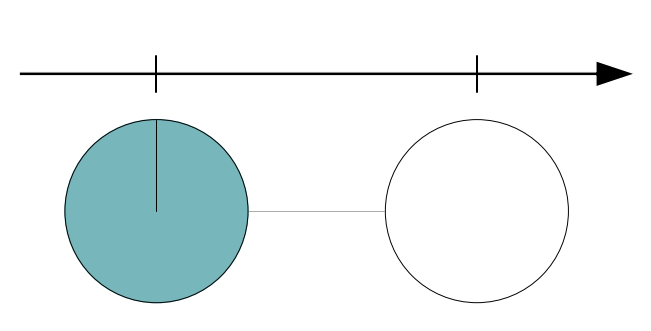
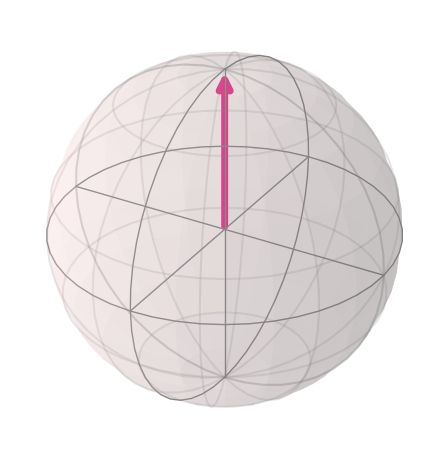
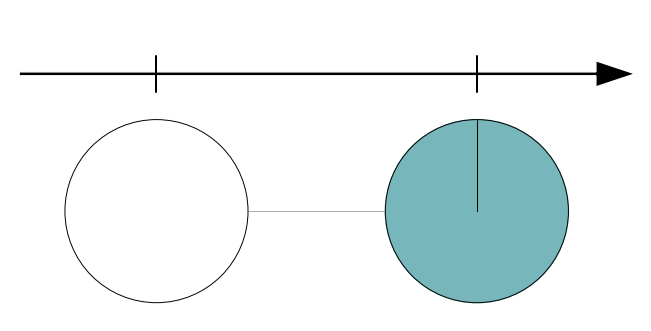
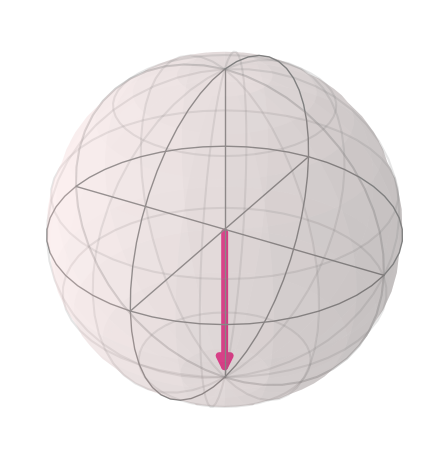
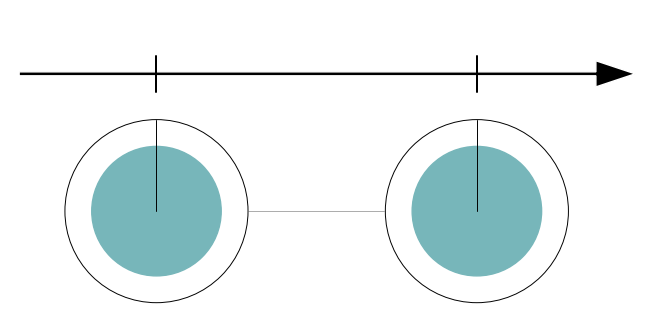
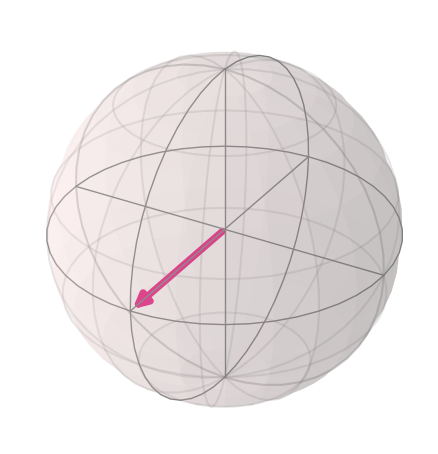
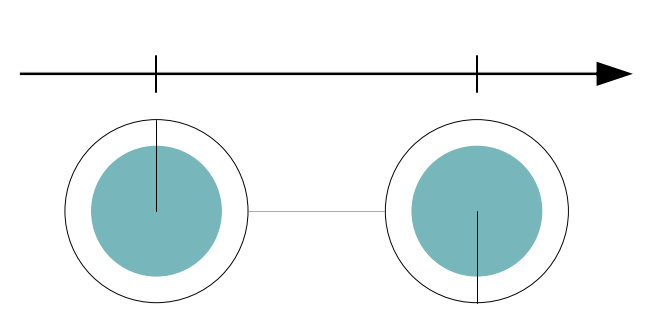
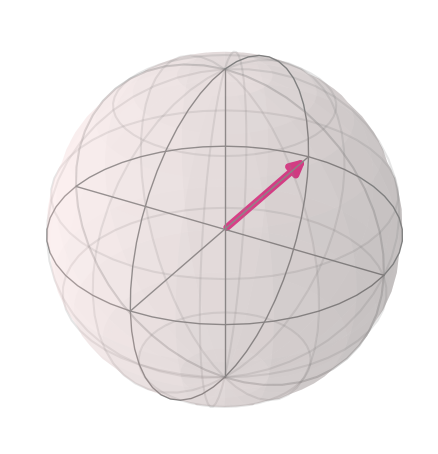

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML

# Qiskit imports
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_bloch_multivector

# Custom Package Imports
from qc_interactive_education_package import Simulator, DimensionalCircleNotation

def fig_to_base64(fig):
    """Converts a matplotlib figure to a base64 string for HTML embedding."""
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
    plt.close(fig) # Close to prevent double plotting
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def latex_to_html(latex_obj):
    """Extracts raw LaTeX string from Qiskit's Latex object."""
    # The Latex object usually stores the string in .data
    # We strip the $$ delimiters if present to control formatting manually
    return latex_obj.data.replace('$$', '')

# Define the 4 states with their metadata
# Format: (Label, Basis, Bit Value, Amplitudes [alpha, beta])
states_data = [
    ("|0\\rangle", "Z (Standard)", "0", [1, 0]),
    ("|1\\rangle", "Z (Standard)", "1", [0, 1]),
    ("|+\\rangle", "X (Hadamard)", "0", [1/np.sqrt(2), 1/np.sqrt(2)]),
    ("|-\\rangle", "X (Hadamard)", "1", [1/np.sqrt(2), -1/np.sqrt(2)])
]

# Start building the HTML Table
html_table = """
<style>
    table.qtable {width: 100%; border-collapse: collapse; text-align: center;}
    table.qtable th {background-color: #f2f2f2; padding: 10px; border: 1px solid #ddd;}
    table.qtable td {padding: 10px; border: 1px solid #ddd; vertical-align: middle;}
    .math-font {font-size: 1.2em;}
</style>
<table class="qtable">
    <tr>
        <th>State Name</th>
        <th>Basis / Bit</th>
        <th>Vector Representation</th>
        <th>Circle Notation (CN)</th>
        <th>Bloch Sphere</th>
    </tr>
"""

# Loop through data to generate rows
for label, basis, bit, amps in states_data:
    # 1. Create Statevector
    psi = Statevector(amps, dims=(2,))

    # 2. Generate LaTeX Math
    latex_obj = array_to_latex(psi, prefix=f"{label} = ")
    math_str = f"$${latex_to_html(latex_obj)}$$"

    # 3. Generate DCN Image
    b64_dcn = DimensionalCircleNotation.from_qiskit(psi).exportBase64("png")

    # 4. Generate Bloch Sphere Image
    bloch_fig = plot_bloch_multivector(psi)
    b64_bloch = fig_to_base64(bloch_fig)

    # 5. Add Row to Table
    html_table += f"""
    <tr>
        <td class="math-font"><b>$${label}$$</b></td>
        <td>
            <b>Basis:</b> {basis}<br>
            <b>Bit Value:</b> {bit}
        </td>
        <td>{math_str}</td>
        <td><img src="data:image/png;base64,{b64_dcn}" width="200"></td>
        <td><img src="data:image/png;base64,{b64_bloch}" width="200"></td>
    </tr>
    """

html_table += "</table>"

# Display the final HTML table
display(HTML(html_table))

In the notebooks below, you will learn how to implement the protocol in python and figure out what changes when an Eavesdropper is introduced.

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Complete the code below to generate Alice's random bits and create the quantum circuit that represents the message sent to Bob.
</div>

In [2]:
# Import necessary libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import numpy as np

# Set the length of the message
n = 100

# 1. Generate random bits for data and bases
alice_bits = np.random.randint(2, size=n)
alice_bases = np.random.randint(2, size=n)

print(f"Alice's first 10 bits: {alice_bits[:10]}")
print(f"Alice's first 10 bases: {alice_bases[:10]}")

def encode_message(bits, bases):
    message = [] # List to store the single-qubit circuits
    for i in range(n):
        qc = QuantumCircuit(1, 1) # Create a circuit with 1 qubit and 1 classical bit

        # TODO: Prepare the qubit state based on the bit and basis
        if bits[i] == 1:
            pass # TODO: Apply the right gate(s)

        if bases[i] == 1:
            pass # TODO: Apply the right gate(s)

        qc.barrier() # Visual separation
        statevector = Statevector.from_instruction(qc)
        message.append(statevector)
    return message

# Create the message
message_to_bob = encode_message(alice_bits, alice_bases)
print("Alice has encoded her qubits.")

Alice's first 10 bits: [1 0 0 1 0 0 1 0 0 0]
Alice's first 10 bases: [1 0 0 1 0 1 0 1 0 1]
Alice has encoded her qubits.


## Step 2: Bob Measures the Qubits

Bob receives the qubits. However, he does not know which basis Alice used for each qubit. He must guess!

Bob generates his own random sequence of Basis Bits.

* If his basis bit is 0, he measures in the Z Basis.
* If his basis bit is 1, he measures in the X Basis (applies H, then measures).

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Simulate Bob's measurement. Think about the right gates for Bob to perform.
</div>

In [3]:
from qiskit_aer import AerSimulator

# 1. Generate Bob's random bases
bob_bases = np.random.randint(2, size=n)

print(f"Bob's first 10 bases:  {bob_bases[:10]}")

def measure_message(message, bases):
    backend = AerSimulator() # Use the local simulator
    measurements = []

    for i in range(n):
        qc = QuantumCircuit(1, 1)
        qc.initialize(message[i], 0) # Get the circuit for the i-th qubit

        # TODO: Apply measurement logic
        if bases[i] == 1:
            pass # TODO: Apply the right gate(s)

        qc.measure(0, 0) # Measure qubit 0 into classical bit 0

        # Run simulation
        result = backend.run(qc, shots=1, memory=True).result()
        measured_bit = int(result.get_memory()[0]) # Get the measured bit
        measurements.append(measured_bit)

    return measurements

# Bob measures the received qubits
bob_results = measure_message(message_to_bob, bob_bases)
print(f"Bob's first 10 results: {bob_results[:10]}")

Bob's first 10 bases:  [0 1 0 0 0 0 0 1 1 1]
Bob's first 10 results: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Step 3: Sifting the Key

Now, Alice and Bob communicate over a classical public channel. They compare their bases (not the bits!).

* If Alice and Bob used the same basis for a specific bit, their measurements are correlated (deterministic). They keep this bit for their secret key.
* If they used different bases, the result is random (50% chance of 0 or 1). They discard this bit.

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Implement the sifting process. Iterate through the lists and keep only the bits where alice_bases[i] == bob_bases[i].
</div>

In [4]:
def sift_key(alice_bases, bob_bases, bob_measurements):
    sifted_key = []

    for i in range(len(alice_bases)):
        # TODO: Compare bases
        # If the bases match, append Bob's measured bit to the sifted_key
        pass

    return sifted_key

# Create the secret key
alice_key = sift_key(alice_bases, bob_bases, alice_bits) # Ideally Alice's bits match Bob's results
bob_key = sift_key(alice_bases, bob_bases, bob_results)

print(f"Key length: {len(bob_key)}")
print(f"Percentage of bits kept: {len(bob_key)/n * 100}% (Should be ~50%)")
print(f"Do the keys match? {alice_key == bob_key}")

Key length: 0
Percentage of bits kept: 0.0% (Should be ~50%)
Do the keys match? True


## Step 4: Introducing Eve (The Eavesdropper)

Now, let's see what happens if an eavesdropper, Eve, tries to intercept the message.
Eve intercepts the qubits coming from Alice before they reach Bob. She doesn't know the bases either, so she measures them in random bases and then sends a new qubit to Bob based on her measurement result.

This is an Attack. Because of the No-Cloning Theorem and the collapse of the wavefunction upon measurement, Eve disturbs the state.

Your Task:

* Create `eve_bases`.
* Have Eve measure Alice's message (this collapses the states in the measurement basis).
* Have Eve prepare new qubits based on her results to send to Bob.
* Run the sifting protocol again between Alice and Bob and check for errors.

In [5]:
# 1. Generate Eve's random bases
eve_bases = np.random.randint(2, size=n)

def intercept_and_resend(message, eve_bases):
    backend = AerSimulator()
    eve_measurements = []
    new_message_to_bob = []

    for i in range(n):
        qc = QuantumCircuit(1, 1)
        qc.initialize(message[i], 0) # Get the circuit for the i-th qubit

        # --- EVE INTERCEPTS ---
        # TODO: Eve applies the right gate(s) to change the basis of measurement
        if eve_bases[i] == 1:
            pass

        qc.measure(0, 0)

        # Eve gets a result
        result = backend.run(qc, shots=1, memory=True).result()
        eve_bit = int(result.get_memory()[0])
        eve_measurements.append(eve_bit)

        # --- EVE RESENDS ---
        # Eve must create a NEW quantum circuit to send to Bob based on what she found.
        new_qc = QuantumCircuit(1, 1)

        # TODO: Prepare new_qc based on eve_bit and eve_bases[i]
        # (Same logic as Alice's encode_message function)
        if eve_bit == 1:
            pass # TODO: Apply the right gate(s)
        if eve_bases[i] == 1:
            pass # TODO: Apply the right gate(s)

        new_message_to_bob.append(new_qc)

    return new_message_to_bob

print("Eve is intercepting...")
intercepted_message = intercept_and_resend(message_to_bob, eve_bases)

# Now Bob measures the message (but it's the one Eve sent!)
bob_results_attacked = measure_message(intercepted_message, bob_bases)

# Sift the keys again
alice_key_attacked = sift_key(alice_bases, bob_bases, alice_bits)
bob_key_attacked = sift_key(alice_bases, bob_bases, bob_results_attacked)

# Calculate Error Rate
errors = 0
for k1, k2 in zip(alice_key_attacked, bob_key_attacked):
    if k1 != k2:
        errors += 1

error_rate = errors / len(bob_key_attacked) if len(bob_key_attacked) > 0 else 0

print(f"New Key Length: {len(bob_key_attacked)}")
print(f"Error Rate: {error_rate * 100:.2f}%")

Eve is intercepting...


QiskitError: 'Sum of amplitudes-squared is not 1, but 0.0.'

## Conclusion

If there were no eavesdropper, the Error Rate should be 0% (assuming perfect hardware).

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: What error rate do you see and why?
</div>
<p>
<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #ffffff;">
   <ul>
  <li>50% of the time, Eve chooses the wrong basis to measure.</li>
  <li>When she chooses the wrong basis, she randomizes the state (e.g., measures ∣0⟩ in X-basis → sends ∣+⟩ or ∣−⟩).</li>
  <li>Even if Bob chooses the correct basis (matching Alice), Eve's randomized state gives him the wrong result 50% of the time.</li>
  <li>Total Error Probability = 0.5 (Eve wrong basis)×0.5 (Bob wrong result)=0.25.</li>
</ul>
</div>
</details>
<p>

By comparing a small subset of their sifted keys, Alice and Bob can detect this error rate. If it's too high, they know Eve is listening and discard the key!

## References

[1] Bennett, C. H., & Brassard, G. (1984, August). An update on quantum cryptography. In Workshop on the theory and application of cryptographic techniques (pp. 475-480). Berlin, Heidelberg: Springer Berlin Heidelberg.